# Desafío - Predicción de renuncia de clientes

### 1. Importa las librerías necesarias para aplicar preprocesamiento de datos, visualización y creación de un modelo de red neuronal feedforward con Keras y Tensorflow. Importa la base de datos Customer Churn.csv y realiza el preprocesamiento de los datos

In [1]:
# Importamos librerias.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, roc_curve, roc_auc_score, auc

import tensorflow as tf
import keras as keras
from keras.models import Sequential 
from keras.layers import Dense 
from keras.optimizers import SGD 

# Definimos una semilla para obtener resultados reproducibles.
RANDOM_STATE = 42

# Fijamos la semilla de numpy para reproducibilidad.
np.random.seed(RANDOM_STATE)

# Fijamos la semilla de TensorFlow para reproducibilidad.
tf.random.set_seed(RANDOM_STATE)

# Configuramos el estilo visual de seaborn.
sns.set(style='whitegrid')

In [2]:
# Definimos la ruta del archivo CSV entregado para el desafío.
DATA_PATH = 'Customer Churn.csv'

# Cargamos la base de datos en un DataFrame de pandas.
df = pd.read_csv(DATA_PATH)

# Mostramos las primeras cinco filas para revisar la estructura inicial de los datos.
display(df.head())

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [3]:
# Mostramos la cantidad de filas y columnas del DataFrame.
print('Dimensiones del DataFrame:', df.shape)

# Mostramos información general de columnas, tipos de datos y valores no nulos.
df.info()

Dimensiones del DataFrame: (3150, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null  

In [4]:
# Revisamos si existen valores ausentes por columna.
tabla_nulos = pd.DataFrame({
    'Valores ausentes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().mean() * 100).round(2)
})

# Ordenamos la tabla de nulos de mayor a menor porcentaje.
tabla_nulos = tabla_nulos.sort_values(by='Porcentaje (%)', ascending=False)

# Mostramos la tabla de valores ausentes.
display(tabla_nulos)

,Valores ausentes,Porcentaje (%)
Call Failure,0,0.0
Complains,0,0.0
Subscription Length,0,0.0
Charge Amount,0,0.0
Seconds of Use,0,0.0
Frequency of use,0,0.0
Frequency of SMS,0,0.0
Distinct Called Numbers,0,0.0
Age Group,0,0.0
Tariff Plan,0,0.0


In [5]:
# Eliminamos espacios extra en los nombres de columnas para facilitar el trabajo posterior.
df.columns = df.columns.str.strip()

# Reemplazamos dobles espacios internos por un solo espacio en los nombres de columnas.
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)

# Mostramos los nombres de columnas ya limpiados.
print(df.columns.tolist())

['Call Failure', 'Complains', 'Subscription Length', 'Charge Amount', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age', 'Customer Value', 'Churn']


In [6]:
# Creamos una copia del DataFrame original para trabajar el preprocesamiento sin modificar df directamente.
df_prep = df.copy()

# Verificamos nuevamente las primeras filas del DataFrame preparado.
display(df_prep.head())

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


Se cargó correctamente la base de datos, obteniéndose un conjunto de 3.150 registros y 14 variables. La revisión inicial permitió verificar la estructura de los datos y los tipos de variables presentes, observándose principalmente atributos numéricos.

El análisis de valores ausentes mostró que ninguna variable presenta datos faltantes, por lo que no fue necesario aplicar técnicas de imputación o eliminación de registros.

Finalmente, se realizó una limpieza de los nombres de las columnas para estandarizar su formato y facilitar el procesamiento posterior, además de generar una copia de trabajo del conjunto de datos para preservar la información original durante las etapas de preprocesamiento y modelado.

### 2. Analiza la distribución de “Subscription Length” para cada clase (Churn), describiendo si hay alguna incidencia de esta variable en la renuncia o no. Realiza una estandarización de las variables regresoras

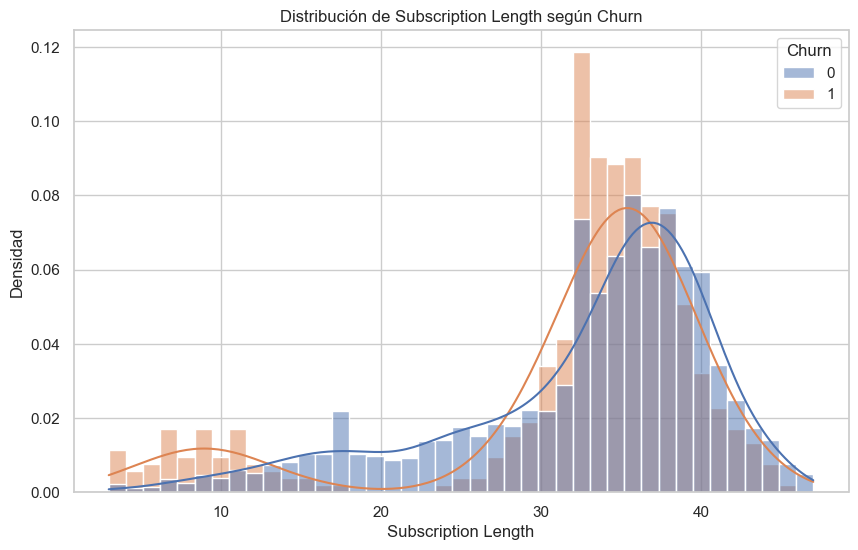

In [7]:
# Creamos una figura para visualizar la distribución de Subscription Length según Churn.
plt.figure(figsize=(10, 6))

# Graficamos histogramas separados por clase de Churn usando densidad para comparar distribuciones.
sns.histplot(
    data=df_prep,
    x='Subscription Length',
    hue='Churn',
    kde=True,
    stat='density',
    common_norm=False
)

# Agregamos título al gráfico.
plt.title('Distribución de Subscription Length según Churn')

# Agregamos etiqueta al eje X.
plt.xlabel('Subscription Length')

# Agregamos etiqueta al eje Y.
plt.ylabel('Densidad')

# Mostramos el gráfico.
plt.show()

La variable Subscription Length presenta diferencias entre ambas clases de Churn, observándose que los clientes que renuncian tienden a tener una antigüedad ligeramente menor. No obstante, existe un importante solapamiento entre las distribuciones, por lo que esta variable por sí sola no permite explicar completamente la renuncia de los clientes.

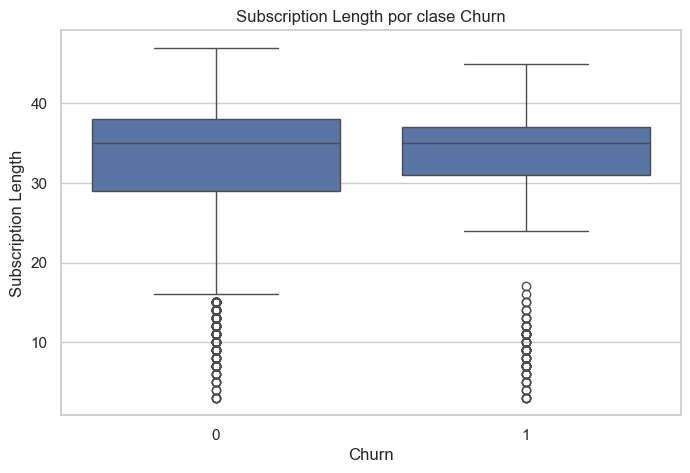

In [8]:
# Creamos una figura para comparar Subscription Length por clase mediante boxplot.
plt.figure(figsize=(8, 5))

# Generamos un boxplot de Subscription Length separado por Churn.
sns.boxplot(data=df_prep, x='Churn', y='Subscription Length')

# Agregamos título al gráfico.
plt.title('Subscription Length por clase Churn')

# Agregamos etiqueta al eje X.
plt.xlabel('Churn')

# Agregamos etiqueta al eje Y.
plt.ylabel('Subscription Length')

# Mostramos el gráfico.
plt.show()

El boxplot confirma que las distribuciones de Subscription Length para ambas clases son muy similares, con medianas cercanas y un amplio solapamiento entre los rangos intercuartílicos. Aunque los clientes que renuncian presentan una antigüedad ligeramente menor, la diferencia no parece ser lo suficientemente marcada como para considerar esta variable como un factor determinante de la renuncia por sí sola.

In [9]:
# Calculamos estadísticas descriptivas de Subscription Length agrupadas por Churn.
subscription_summary = df_prep.groupby('Churn')['Subscription Length'].describe()

# Mostramos el resumen estadístico.
display(subscription_summary)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,2655.0,32.662524,8.392357,3.0,29.0,35.0,38.0,47.0
1,495.0,31.894949,9.469163,3.0,31.0,35.0,37.0,45.0


Las estadísticas descriptivas muestran que los clientes que permanecen en la compañía (Churn = 0) presentan una antigüedad promedio ligeramente superior (32.66 meses) respecto a los clientes que renuncian (31.89 meses). Sin embargo, las medianas son iguales (35 meses en ambos grupos) y los rangos intercuartílicos presentan un alto grado de solapamiento.

Estos resultados refuerzan la idea de que Subscription Length tiene cierta relación con la renuncia, pero su capacidad explicativa individual es limitada, por lo que resulta más útil al combinarse con otras variables dentro de los modelos predictivos.

In [10]:
# Variables predictoras
X = df.drop(columns=['Churn'])

# Variable objetivo
y = df['Churn']

# Inicializar StandardScaler
scaler = StandardScaler()

# Estandarizar variables regresoras
X_scaled = scaler.fit_transform(X)

# Convertir nuevamente a DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# Verificar resultado
display(X_scaled.head())

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value
0,0.051229,-0.28783,0.636726,-0.619962,-0.024411,0.026816,-0.607513,-0.378158,0.194941,-0.290409,-0.574662,-0.113074,-0.528759
1,-1.050285,-0.28783,0.753384,-0.619962,-0.989807,-1.122926,-0.589691,-1.133331,-0.925616,-0.290409,1.740153,-0.679346,-0.822036
2,0.326608,-0.28783,0.520069,-0.619962,-0.481140,-0.164807,2.547012,0.028473,0.194941,-0.290409,-0.574662,-0.113074,2.061285
3,0.326608,-0.28783,0.636726,-0.619962,-0.065390,-0.060285,-0.643157,0.667466,-2.046172,-0.290409,-0.574662,-1.811888,-0.446775
4,-0.637217,-0.28783,0.636726,-0.619962,-0.495435,-0.199648,-0.634246,0.551285,-2.046172,-0.290409,-0.574662,-1.811888,-0.629033


### Estandarización de variables

Debido a que las variables presentan diferentes escalas de medición, se aplicó una estandarización mediante StandardScaler. Este procedimiento transforma cada variable para que tenga media cercana a 0 y desviación estándar cercana a 1, evitando que atributos con magnitudes mayores dominen el proceso de entrenamiento de los modelos posteriores.

## 3. Muestra la frecuencia de cada clase y realiza un balanceo de clase usando SMOTE. Divida el conjunto de datos en entrenamiento y test, considerando para este último un 33%.


### Frecuencia

In [11]:
# Calculamos la frecuencia absoluta de cada clase de Churn.
frecuencia_clases = df_prep['Churn'].value_counts()

# Calculamos la frecuencia relativa de cada clase de Churn.
proporcion_clases = df_prep['Churn'].value_counts(normalize=True).round(3)

# Mostramos la frecuencia absoluta.
print('Frecuencia absoluta de Churn:')
print(frecuencia_clases)

# Mostramos la frecuencia relativa.
print('Frecuencia relativa de Churn:')
print(proporcion_clases)

Frecuencia absoluta de Churn:
Churn
0    2655
1     495
Name: count, dtype: int64
Frecuencia relativa de Churn:
Churn
0    0.843
1    0.157
Name: proportion, dtype: float64


La variable objetivo Churn presenta un desbalance de clases significativo. La clase 0 (clientes que permanecen) representa el 84.3% de las observaciones, mientras que la clase 1 (clientes que renuncian) corresponde únicamente al 15.7%. Esta diferencia puede generar sesgos en los modelos predictivos, favoreciendo la clasificación de la clase mayoritaria. Por esta razón, resulta necesario aplicar técnicas de balanceo como SMOTE antes del entrenamiento de los modelos.

In [ ]:
# División entrenamiento/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.33,
    random_state=RANDOM_STATE,
    stratify=y
)
# Verificamos las dimensiones de los conjuntos resultantes.
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2110, 13)
X_test : (1040, 13)
y_train: (2110,)
y_test : (1040,)


El conjunto de datos fue dividido en 67% para entrenamiento y 33% para prueba, obteniéndose 2110 observaciones para entrenamiento y 1040 observaciones para test. Además, se utilizó estratificación sobre la variable objetivo (stratify=y), asegurando que la proporción de clientes que permanecen y renuncian se mantenga similar en ambos conjuntos. Esta división permite entrenar los modelos y posteriormente evaluar su desempeño sobre datos no vistos.

In [13]:
# Inicializar SMOTE
smote = SMOTE(random_state=RANDOM_STATE)

# Aplicar SMOTE al conjunto de entrenamiento
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

Para abordar el desbalance de clases identificado previamente, se aplicó la técnica SMOTE (Synthetic Minority Over-sampling Technique) sobre el conjunto de entrenamiento. Este método genera observaciones sintéticas de la clase minoritaria a partir de los datos existentes, permitiendo equilibrar la representación de ambas clases sin afectar el conjunto de prueba. De esta forma, los modelos posteriores podrán entrenarse sobre un conjunto más balanceado y menos sesgado hacia la clase mayoritaria.

In [ ]:
# Verificamos las dimensiones del conjunto de entrenamiento antes de SMOTE.
print("Antes de SMOTE:")
print(y_train.value_counts())

# Verificamos las dimensiones del conjunto de entrenamiento después de aplicar SMOTE.
print("\nDespués de SMOTE:")
print(y_train_smote.value_counts())

Antes de SMOTE:
Churn
0    1778
1     332
Name: count, dtype: int64

Después de SMOTE:
Churn
0    1778
1    1778
Name: count, dtype: int64


La aplicación de SMOTE permitió balancear completamente las clases del conjunto de entrenamiento. Antes del balanceo, la clase mayoritaria contaba con 1778 observaciones, mientras que la clase minoritaria tenía solo 332. Después de aplicar SMOTE, ambas clases quedaron representadas con 1778 observaciones, eliminando el desbalance inicial y proporcionando condiciones más adecuadas para el entrenamiento de los modelos de clasificación.

### 4. Entrene un modelo RandomForest con hiper parámetros por defecto, usando el conjunto de entrenamiento anterior y muestra la métrica F1-Score para ambas clases en el conjunto de test. Captura y muestra las siete características más importantes detectadas por el modelo RandomForest.

In [15]:
# Inicializamos un modelo RandomForest con hiperparámetros por defecto.
rf_model = RandomForestClassifier(random_state=RANDOM_STATE)

# Entrenamos RandomForest con el conjunto de entrenamiento balanceado.
rf_model.fit(X_train_smote, y_train_smote)

# Generamos predicciones sobre el conjunto de test estandarizado.
y_pred_rf = rf_model.predict(X_test)

# Mostramos el reporte de clasificación, incluyendo F1-score para ambas clases.
print('Classification Report - Random Forest')
print(classification_report(y_test, y_pred_rf))

Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       877
           1       0.83      0.93      0.88       163

    accuracy                           0.96      1040
   macro avg       0.91      0.95      0.93      1040
weighted avg       0.96      0.96      0.96      1040



El modelo Random Forest, entrenado con el conjunto balanceado mediante SMOTE, obtuvo un desempeño muy satisfactorio en el conjunto de prueba. El F1-score alcanzó 0.98 para la clase 0 y 0.88 para la clase 1, lo que indica una buena capacidad para clasificar correctamente tanto a los clientes que permanecen como a aquellos que renuncian.

Además, el modelo logró una exactitud global del 96%, mostrando un adecuado equilibrio entre precisión y recall en ambas clases. Estos resultados sugieren que Random Forest es capaz de capturar eficazmente los patrones presentes en los datos y constituye una base sólida para identificar las variables más relevantes del problema.

In [16]:
# Creamos un DataFrame con la importancia de variables del RandomForest.
importancias_rf = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf_model.feature_importances_
})

# Ordenamos las variables desde mayor a menor importancia.
importancias_rf = importancias_rf.sort_values(by='Importancia', ascending=False)

# Seleccionamos las siete variables más importantes.
top_7_features = importancias_rf.head(7)['Variable'].tolist()

# Mostramos la tabla de las siete variables más importantes.
display(importancias_rf.head(7))

# Mostramos la lista de variables seleccionadas.
print('Top 7 características:', top_7_features)

,Variable,Importancia
10,Status,0.157947
5,Frequency of use,0.133783
1,Complains,0.124141
4,Seconds of Use,0.123578
2,Subscription Length,0.107180
7,Distinct Called Numbers,0.080836
12,Customer Value,0.080772


Top 7 características: ['Status', 'Frequency of use', 'Complains', 'Seconds of Use', 'Subscription Length', 'Distinct Called Numbers', 'Customer Value']


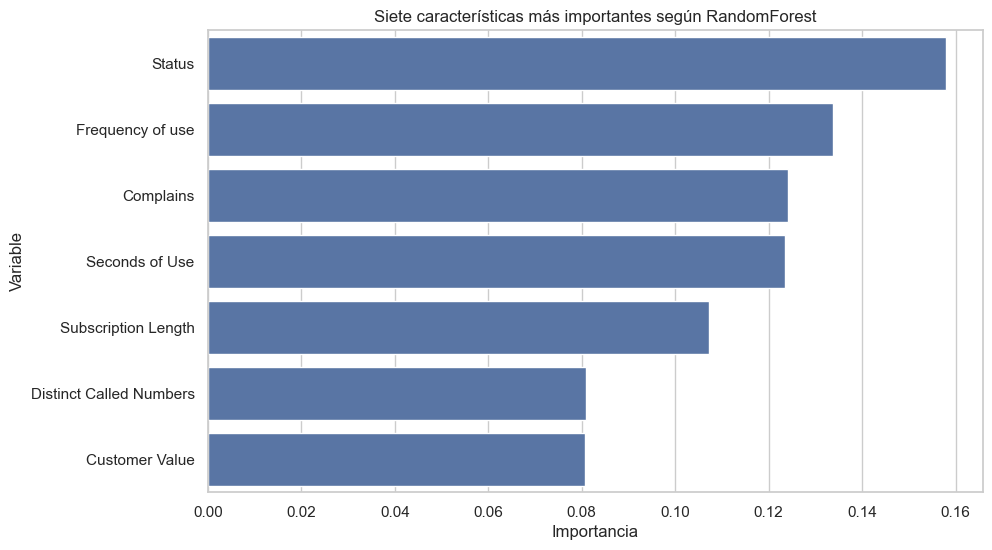

In [17]:
# Creamos una figura para visualizar las siete variables más importantes.
plt.figure(figsize=(10, 6))

# Graficamos la importancia de las siete principales variables.
sns.barplot(data=importancias_rf.head(7), x='Importancia', y='Variable')

# Agregamos título al gráfico.
plt.title('Siete características más importantes según RandomForest')

# Agregamos etiqueta al eje X.
plt.xlabel('Importancia')

# Agregamos etiqueta al eje Y.
plt.ylabel('Variable')

# Mostramos el gráfico.
plt.show()

El modelo Random Forest identificó siete variables con mayor influencia en la predicción de abandono de clientes. Las características más importantes fueron Status, Frequency of use, Complains, Seconds of Use, Subscription Length, Distinct Called Numbers y Customer Value.

Entre ellas, Status y Frequency of use presentan los mayores niveles de importancia, lo que sugiere que el comportamiento de uso del servicio y el estado del cliente son factores clave para explicar la renuncia.

### 5. Usando las siete características encontradas anteriormente, filtra el conjunto de entrenamiento y entrena un modelo de red neuronal feedforward con sólo una capa oculta. Para esto debes definir una función de activación adecuada, tanto para la capa oculta como para la capa de salida, la cantidad de neuronas a usar, la tasa de aprendizaje (learning_rate), y la cantidad de épocas deben ser ajustadas manualmente. Como optimizador, utiliza el Descenso del Gradiente Estocástico. Los ajustes manuales de los hiper parámetros deben ser tales que la métrica AUC sea mayor al 90%. Muestra finalmente ROC y su AUC.

In [18]:
# Filtramos el conjunto de entrenamiento SMOTE usando solo las siete variables más importantes.
X_train_nn = X_train_smote[top_7_features]

# Filtramos el conjunto de test usando solo las siete variables más importantes.
X_test_nn = X_test[top_7_features]

# Mostramos las dimensiones del conjunto de entrenamiento para la red neuronal.
print('X_train_nn:', X_train_nn.shape)

# Mostramos las dimensiones del conjunto de prueba para la red neuronal.
print('X_test_nn:', X_test_nn.shape)

X_train_nn: (3556, 7)
X_test_nn: (1040, 7)


Se seleccionaron las siete variables más importantes identificadas por Random Forest y se utilizaron para construir los conjuntos de entrenamiento y prueba de la red neuronal. Tras el filtrado, el conjunto de entrenamiento quedó compuesto por 3556 observaciones y 7 variables, mientras que el conjunto de prueba mantuvo 1040 observaciones y 7 variables.

Esta selección permite reducir la complejidad del modelo, concentrando el aprendizaje en las características con mayor capacidad predictiva y facilitando el entrenamiento de la red neuronal sin perder información relevante para la clasificación del abandono de clientes.

In [ ]:
# Definimos la cantidad de variables de entrada (7) de la red neuronal.
n_inputs = X_train_nn.shape[1]

# Creamos un modelo secuencial de Keras.
nn_model = keras.Sequential()

# Agregamos una capa oculta con 16 neuronas y activación ReLU.
nn_model.add(Dense(16, activation='relu', input_shape=(n_inputs,)))

# Agregamos la capa de salida con una neurona y activación sigmoid para clasificación binaria.
nn_model.add(Dense(1, activation='sigmoid'))

# Definimos el optimizador SGD con una tasa de aprendizaje ajustada manualmente.
optimizer = SGD(learning_rate=0.01)

# Compilamos el modelo indicando función de pérdida binaria, optimizador y métrica AUC.
nn_model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy',tf.keras.metrics.AUC(name='auc')]
)

# Mostramos el resumen de la arquitectura del modelo.
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145 (580.00 B)

 Trainable params: 145 (580.00 B)

 Non-trainable params: 0 (0.00 B)

Se construyó una red neuronal feedforward utilizando las siete variables más relevantes seleccionadas previamente. La arquitectura definida contempla una única capa oculta con 16 neuronas y función de activación ReLU, mientras que la capa de salida utiliza una neurona con función sigmoide, adecuada para problemas de clasificación binaria como la predicción de abandono de clientes.

Además, se empleó el optimizador Descenso del Gradiente Estocástico (SGD) con una tasa de aprendizaje de 0.01, configurando una arquitectura simple pero suficiente para capturar los patrones presentes en los datos. El modelo cuenta con 145 parámetros entrenables, los cuales serán ajustados durante el proceso de entrenamiento para maximizar su capacidad predictiva.

In [20]:
# Entrenamos la red neuronal con los datos balanceados y las siete variables seleccionadas.
history = nn_model.fit(
    X_train_nn,
    y_train_smote,
    epochs=200,
    validation_split=0.25,  
    batch_size=32,
    verbose=1
)

Epoch 1/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5167 - auc: 0.2993 - loss: 0.7593 - val_accuracy: 0.1721 - val_auc: 0.0000e+00 - val_loss: 0.9237
Epoch 2/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6753 - auc: 0.6463 - loss: 0.6164 - val_accuracy: 0.5051 - val_auc: 0.0000e+00 - val_loss: 0.7406
Epoch 3/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7627 - auc: 0.8177 - loss: 0.5379 - val_accuracy: 0.6985 - val_auc: 0.0000e+00 - val_loss: 0.6406
Epoch 4/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8009 - auc: 0.8769 - loss: 0.4862 - val_accuracy: 0.7435 - val_auc: 0.0000e+00 - val_loss: 0.5771
Epoch 5/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8211 - auc: 0.8988 - loss: 0.4486 - val_accuracy: 0.8088 - val_auc: 0.0000e+00 - val_loss: 0.5342
Epoch 6/200
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8406 - auc: 0.9102 - loss: 0.4201 - val_accuracy: 0.8155 - val_auc: 0.0000e+00 - val_loss: 0.5061
Epoch 7/200
84/84 ━━━━

La red neuronal fue entrenada utilizando el conjunto de entrenamiento balanceado mediante SMOTE y las siete variables seleccionadas previamente. Durante las 200 épocas de entrenamiento, el modelo mostró una mejora progresiva en su desempeño, alcanzando un AUC de entrenamiento cercano a 0.96 y una accuracy de validación cercano al 90%.

Estos resultados indican que la arquitectura propuesta, junto con los hiperparámetros seleccionados manualmente (16 neuronas, función ReLU, optimizador SGD y learning rate de 0.01), logra aprender adecuadamente los patrones presentes en los datos y presenta una buena capacidad de generalización para la predicción del abandono de clientes.

In [ ]:
# Mostramos las claves disponibles en el objeto history para revisar métricas de entrenamiento y validación.
history.history.keys()

dict_keys(['accuracy', 'auc', 'loss', 'val_accuracy', 'val_auc', 'val_loss'])

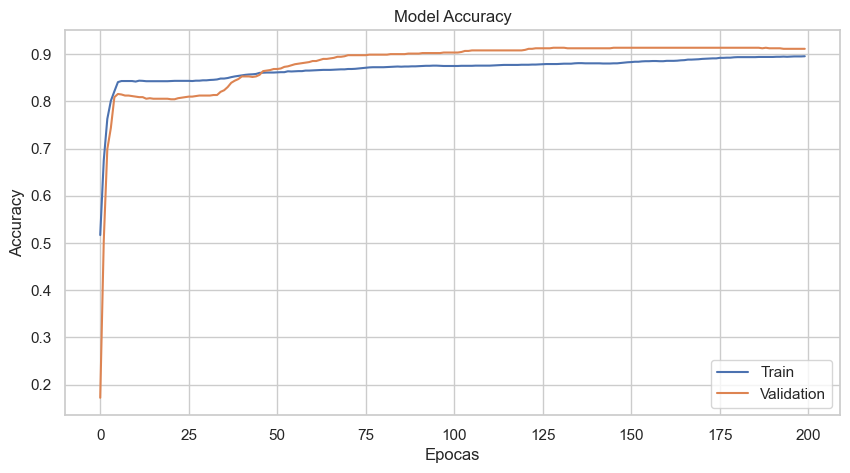

In [ ]:
# Graficamos la evolución del Accuracy durante el entrenamiento y validación.
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epocas')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

El modelo presenta una buena capacidad de generalización, ya que el desempeño sobre entrenamiento y validación es muy similar.

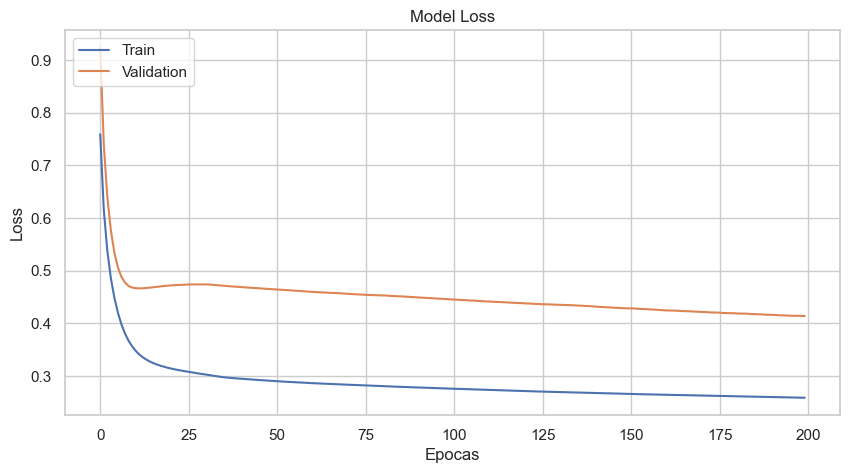

In [ ]:
# Graficamos la evolución de la pérdida (loss) durante el entrenamiento y validación.
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epocas')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

El proceso de entrenamiento fue estable y el modelo logró minimizar progresivamente el error tanto en entrenamiento como en validación.

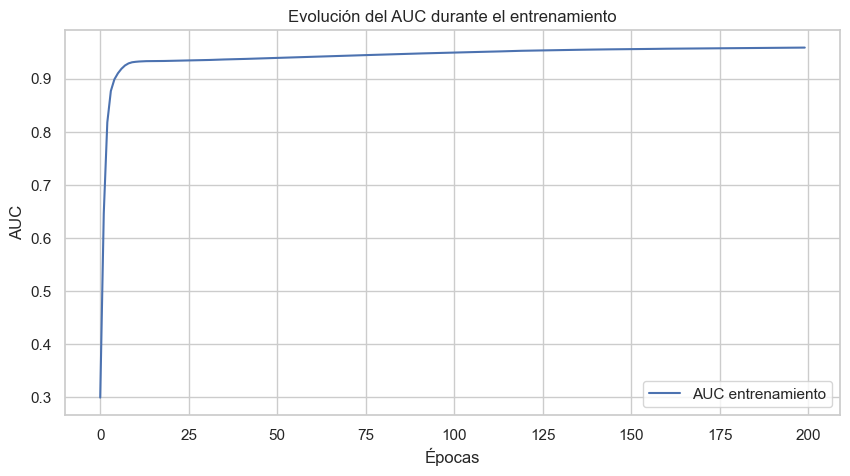

In [ ]:
# Graficamos el AUC del conjunto de entrenamiento.
plt.figure(figsize=(10, 5))
plt.plot(history.history['auc'], label='AUC entrenamiento')
plt.title('Evolución del AUC durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('AUC')
plt.legend()
plt.show()

La evolución del AUC durante el entrenamiento muestra una mejora sostenida del desempeño de la red neuronal a medida que avanzan las épocas. El modelo incrementó rápidamente su capacidad de discriminación durante las primeras iteraciones y posteriormente continuó mejorando de forma gradual hasta alcanzar valores cercanos a 0.96.

In [25]:
# Obtenemos las probabilidades predichas para la clase positiva en test.
y_proba_nn = nn_model.predict(X_test_nn).ravel()

# Convertimos probabilidades a clases usando umbral 0.5.
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

# Mostramos el reporte de clasificación de la red neuronal.
print('Classification Report - Red Neuronal')
print(classification_report(y_test, y_pred_nn))

# Calculamos el AUC de la red neuronal en test.
auc_nn = roc_auc_score(y_test, y_proba_nn)

# Mostramos el AUC final.
print('AUC Red Neuronal:', round(auc_nn, 4))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Classification Report - Red Neuronal
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       877
           1       0.60      0.90      0.72       163

    accuracy                           0.89      1040
   macro avg       0.79      0.90      0.83      1040
weighted avg       0.92      0.89      0.90      1040

AUC Red Neuronal: 0.9456


La red neuronal feedforward entrenada con las siete variables más importantes y el conjunto balanceado mediante SMOTE obtuvo un AUC de 0.9456, superando ampliamente el 90% solicitado. Además, alcanzó un recall de 0.90 para la clase de abandono, demostrando una alta capacidad para identificar clientes con riesgo de renuncia y un buen desempeño general en la clasificación.

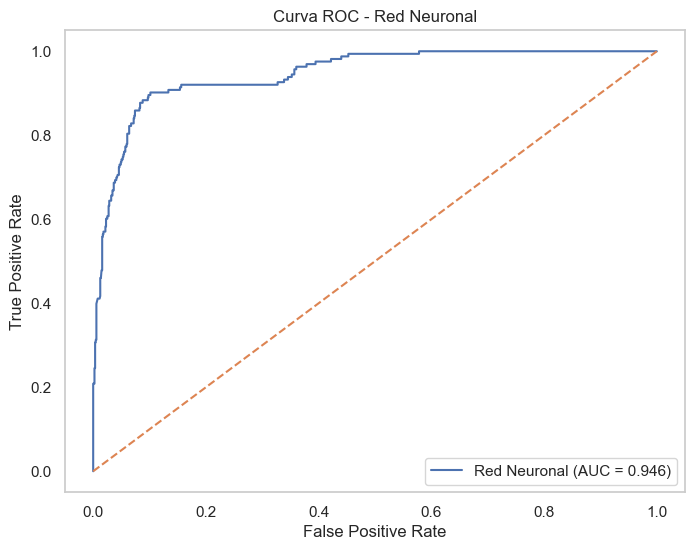

In [ ]:
# Calculamos los valores de FPR y TPR para construir la curva ROC.
fpr, tpr, thresholds = roc_curve(y_test, y_proba_nn)

# Calculamos el área bajo la curva ROC.
roc_auc = auc(fpr, tpr)

# Graficamos la curva ROC del modelo de red neuronal con linea base.
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Red Neuronal (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Curva ROC - Red Neuronal')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

La curva ROC se mantiene muy por encima de la línea de referencia de un clasificador aleatorio, evidenciando una buena capacidad de discriminación entre clientes que abandonan el servicio y aquellos que permanecen. El modelo alcanzó un AUC de 0.9456 (94.56%) aproximando a 94.6%, superando ampliamente el umbral del 90% solicitado y confirmando un desempeño sobresaliente en la predicción del abandono de clientes.